In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")
scheme = pd.read_csv("../data/raw/07_scheme_performance.csv")
investor = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print(nav.head())
print(scheme.head())

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692
   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   
2  Small Cap  Regular           24.56           23.39           20.67   
3  Small Cap   Direct        

In [3]:
print(nav.columns)
print(investor.columns)
print(portfolio.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


In [4]:
nav["date"] = pd.to_datetime(nav["date"])
nav["nav"] = pd.to_numeric(nav["nav"])

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [5]:
risk_report = (
    nav.groupby("amfi_code")["daily_return"]
    .agg(
        VaR=lambda x: np.percentile(
            x.dropna(),5
        ),
        CVaR=lambda x:
        x[
            x <= np.percentile(
                x.dropna(),5
            )
        ].mean()
    )
    .reset_index()
)

risk_report.head()

,amfi_code,VaR,CVaR
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [6]:
risk_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("VaR Report Saved")

VaR Report Saved


In [7]:
fund = nav[
    nav["amfi_code"] ==
    nav["amfi_code"].iloc[0]
].copy()

In [8]:
fund["rolling_sharpe"] = (
    fund["daily_return"]
      .rolling(90)
      .mean()
    /
    fund["daily_return"]
      .rolling(90)
      .std()
) * np.sqrt(252)

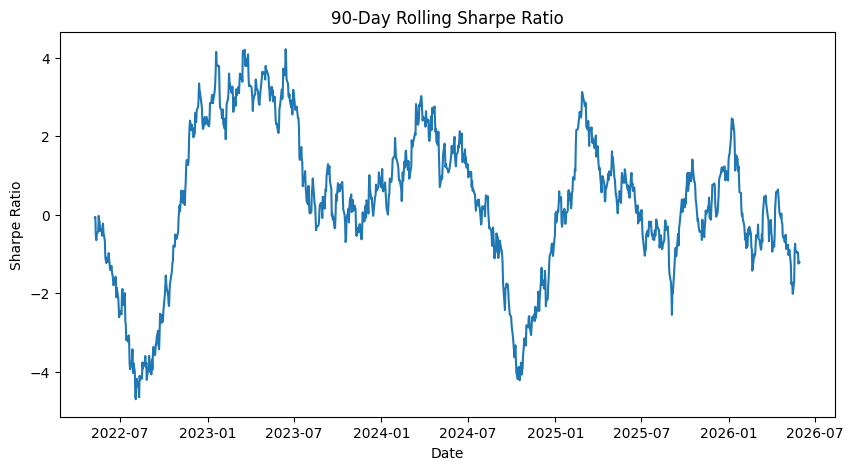

In [9]:
plt.figure(figsize=(10,5))

plt.plot(
    fund["date"],
    fund["rolling_sharpe"]
)

plt.title(
    "90-Day Rolling Sharpe Ratio"
)

plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

plt.show()

In [10]:
investor["transaction_date"] = pd.to_datetime(
    investor["transaction_date"]
)

In [11]:
cohort = (
    investor.groupby("investor_id")
    ["transaction_date"]
    .min()
    .reset_index()
)

cohort["cohort_year"] = (
    cohort["transaction_date"]
    .dt.year
)

cohort.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [12]:
cohort_report = (
    investor.merge(
        cohort[
            ["investor_id","cohort_year"]
        ],
        on="investor_id"
    )
)

cohort_summary = (
    cohort_report.groupby("cohort_year")
    ["amount_inr"]
    .sum()
)

print(cohort_summary)

cohort_year
2024    3491125187
2025      30455243
Name: amount_inr, dtype: int64


In [13]:
sip = investor[
    investor["transaction_type"]=="SIP"
].copy()

In [14]:
sip = sip.sort_values(
    ["investor_id","transaction_date"]
)

sip["gap_days"] = (
    sip.groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)

In [15]:
at_risk = sip[
    sip["gap_days"] > 35
]

print(
    "At Risk Investors:",
    at_risk["investor_id"].nunique()
)

At Risk Investors: 3906
